# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


# Model Building

In [1]:
# Create a master folder to keep all files created when executing the below code cells
import os
os.makedirs("tourism_project", exist_ok=True)

In [2]:
# Create a folder for storing the model building files
os.makedirs("tourism_project/model_building", exist_ok=True)

## Data Registration

In [3]:
os.makedirs("tourism_project/data", exist_ok=True)

Once the **data** folder created after executing the above cell, please upload the **tourism.csv** in to the folder

`data_register.py` below uploads the raw `tourism.csv` to a Hugging Face **dataset** repository, so every later stage of the pipeline (and the GitHub Actions workflow) pulls from one versioned source of truth instead of a local file that could silently change. It only actually uploads when an `HF_TOKEN` is present in the environment (true inside the GitHub Actions pipeline once the secret is set, or in Colab once you load your token from Colab Secrets) — otherwise it prints a clear message and continues, so the cell is always safe to run.

In [4]:
%%writefile tourism_project/model_building/data_register.py
"""
Data Registration
------------------
Registers the raw tourism.csv dataset on the Hugging Face Hub so that every
later pipeline stage (data prep, training) pulls from a single versioned
source of truth instead of a local file.

Usage:
    python data_register.py

Requires:
    HF_TOKEN        - Hugging Face access token with "write" scope
                       (set as an environment variable / GitHub secret)
    HF_USERNAME     - your Hugging Face username (edit the constant below)
"""

import os
from huggingface_hub import HfApi

# ---------------------------------------------------------------------------
# CONFIG - replace with your own Hugging Face username
# ---------------------------------------------------------------------------
HF_USERNAME = "your-hf-username"          # <-- TODO: replace with your HF username
DATASET_REPO_ID = f"{HF_USERNAME}/tourism-package-prediction"

LOCAL_DATA_PATH = "tourism_project/data/tourism.csv"


def main():
    hf_token = os.getenv("HF_TOKEN")

    if not hf_token:
        print(
            "No HF_TOKEN found in the environment. Skipping the upload to the "
            "Hugging Face Hub - the raw file is already available locally at "
            f"'{LOCAL_DATA_PATH}'. Set HF_TOKEN (and HF_USERNAME above) to "
            "register the dataset online."
        )
        return

    api = HfApi(token=hf_token)

    # Create the dataset repo if it does not already exist
    api.create_repo(
        repo_id=DATASET_REPO_ID,
        repo_type="dataset",
        private=False,
        exist_ok=True,
    )

    # Upload the raw CSV
    api.upload_file(
        path_or_fileobj=LOCAL_DATA_PATH,
        path_in_repo="tourism.csv",
        repo_id=DATASET_REPO_ID,
        repo_type="dataset",
    )

    print(f"Raw dataset uploaded to https://huggingface.co/datasets/{DATASET_REPO_ID}")


if __name__ == "__main__":
    main()


Writing tourism_project/model_building/data_register.py


In [5]:
!python tourism_project/model_building/data_register.py

No HF_TOKEN found in the environment. Skipping the upload to the Hugging Face Hub - the raw file is already available locally at 'tourism_project/data/tourism.csv'. Set HF_TOKEN (and HF_USERNAME above) to register the dataset online.


## Data Preparation

We start by loading the raw file and inspecting it before writing any cleaning logic, so every decision below is backed by something we actually observed in the data.

In [6]:
import pandas as pd

raw_df = pd.read_csv("tourism_project/data/tourism.csv")
print("Shape:", raw_df.shape)
raw_df.head()


Shape: (4128, 21)


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [7]:
print("Missing values per column:")
print(raw_df.isnull().sum().sum(), "total missing cells")
print()
print("Duplicate CustomerIDs:", raw_df['CustomerID'].duplicated().sum())
print()
print("Target distribution:")
print(raw_df['ProdTaken'].value_counts(normalize=True).round(3))


Missing values per column:
0 total missing cells

Duplicate CustomerIDs: 0

Target distribution:
ProdTaken
0    0.807
1    0.193
Name: proportion, dtype: float64


In [8]:
# Inspect categorical columns for inconsistent / dirty category labels
for col in raw_df.select_dtypes(include='object').columns:
    print(col, '->', sorted(raw_df[col].dropna().unique().tolist()))


TypeofContact -> ['Company Invited', 'Self Enquiry']
Occupation -> ['Free Lancer', 'Large Business', 'Salaried', 'Small Business']
Gender -> ['Fe Male', 'Female', 'Male']
ProductPitched -> ['Basic', 'Deluxe', 'King', 'Standard', 'Super Deluxe']
MaritalStatus -> ['Divorced', 'Married', 'Single', 'Unmarried']
Designation -> ['AVP', 'Executive', 'Manager', 'Senior Manager', 'VP']


**Observations from the raw data**

- The dataset has no null cells, but it does have data-entry issues: `Gender` contains a `"Fe Male"` typo that should be `"Female"`, and `MaritalStatus` contains both `"Single"` and `"Unmarried"`, which describe the same status and should be merged so the signal isn't split across two categories.
- `Unnamed: 0` and `CustomerID` are row identifiers with no predictive value and should be dropped before modelling.
- The target `ProdTaken` is imbalanced: only ~19% of customers purchased the package. This matters for model selection later — accuracy alone will be a misleading metric, so we will track precision, recall, F1 and ROC-AUC, and select the final model on F1.

These fixes are implemented in `prep.py` below, which also performs the stratified train/test split so the 19%/81% class ratio is preserved in both splits. The script pulls the raw file from the Hugging Face dataset repo when `HF_TOKEN` is set (i.e. when running inside the GitHub Actions pipeline or a configured Colab session) and falls back to the local copy otherwise, so the exact same script works both here and inside the automated pipeline.

In [9]:
%%writefile tourism_project/model_building/prep.py
"""
Data Preparation
-----------------
Loads the raw tourism dataset (from the Hugging Face dataset repo if HF_TOKEN
is available, otherwise from the local data/ folder), cleans it, and produces
a stratified train/test split ready for model training.

Cleaning steps and why:
    * Drop 'Unnamed: 0' and 'CustomerID'  -> identifiers, not predictive.
    * Fix the 'Fe Male' typo in Gender    -> data entry error, same as 'Female'.
    * Merge 'Unmarried' into 'Single' in MaritalStatus -> both describe the
      same status; keeping them separate would artificially split the signal.
    * Cast the target 'ProdTaken' to int.

Usage:
    python prep.py
"""

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from huggingface_hub import hf_hub_download, HfApi

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
HF_USERNAME = "your-hf-username"          # <-- TODO: replace with your HF username
DATASET_REPO_ID = f"{HF_USERNAME}/tourism-package-prediction"

LOCAL_DATA_DIR = "tourism_project/data"
LOCAL_RAW_PATH = f"{LOCAL_DATA_DIR}/tourism.csv"

TARGET = "ProdTaken"
DROP_COLS = ["Unnamed: 0", "CustomerID"]


def load_raw_data(hf_token: str | None) -> pd.DataFrame:
    """Load the raw dataset, preferring the Hugging Face Hub copy when a
    token is available so every pipeline run works off the registered
    (versioned) dataset rather than whatever happens to sit on disk."""
    if hf_token:
        try:
            path = hf_hub_download(
                repo_id=DATASET_REPO_ID,
                filename="tourism.csv",
                repo_type="dataset",
                token=hf_token,
            )
            print(f"Loaded raw data from Hugging Face Hub: {DATASET_REPO_ID}")
            return pd.read_csv(path)
        except Exception as e:
            print(f"Could not fetch dataset from HF Hub ({e}); falling back to local file.")

    print(f"Loaded raw data from local file: {LOCAL_RAW_PATH}")
    return pd.read_csv(LOCAL_RAW_PATH)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].replace({"Fe Male": "Female"})

    if "MaritalStatus" in df.columns:
        df["MaritalStatus"] = df["MaritalStatus"].replace({"Unmarried": "Single"})

    df[TARGET] = df[TARGET].astype(int)

    return df


def main():
    hf_token = os.getenv("HF_TOKEN")

    raw_df = load_raw_data(hf_token)
    clean_df = clean_data(raw_df)

    print(f"Shape after cleaning: {clean_df.shape}")
    print(f"Target distribution:\n{clean_df[TARGET].value_counts(normalize=True).round(3)}")

    X = clean_df.drop(columns=[TARGET])
    y = clean_df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
    X_train.to_csv(f"{LOCAL_DATA_DIR}/Xtrain.csv", index=False)
    X_test.to_csv(f"{LOCAL_DATA_DIR}/Xtest.csv", index=False)
    y_train.to_csv(f"{LOCAL_DATA_DIR}/ytrain.csv", index=False)
    y_test.to_csv(f"{LOCAL_DATA_DIR}/ytest.csv", index=False)

    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print(f"Saved Xtrain.csv, Xtest.csv, ytrain.csv, ytest.csv to '{LOCAL_DATA_DIR}/'")

    if hf_token:
        api = HfApi(token=hf_token)
        api.create_repo(repo_id=DATASET_REPO_ID, repo_type="dataset", private=False, exist_ok=True)
        for fname in ["Xtrain.csv", "Xtest.csv", "ytrain.csv", "ytest.csv"]:
            api.upload_file(
                path_or_fileobj=f"{LOCAL_DATA_DIR}/{fname}",
                path_in_repo=fname,
                repo_id=DATASET_REPO_ID,
                repo_type="dataset",
            )
        print(f"Uploaded processed splits to https://huggingface.co/datasets/{DATASET_REPO_ID}")
    else:
        print("No HF_TOKEN found - processed splits kept local only.")


if __name__ == "__main__":
    main()


Writing tourism_project/model_building/prep.py


In [10]:
!python tourism_project/model_building/prep.py

Loaded raw data from local file: tourism_project/data/tourism.csv


Shape after cleaning: (4128, 19)
Target distribution:
ProdTaken
0    0.807
1    0.193
Name: proportion, dtype: float64
Train shape: (3302, 18), Test shape: (826, 18)
Saved Xtrain.csv, Xtest.csv, ytrain.csv, ytest.csv to 'tourism_project/data/'
No HF_TOKEN found - processed splits kept local only.


The script reports the post-cleaning shape and confirms the target ratio (~19% positive) is preserved after the split, and it has written `Xtrain.csv`, `Xtest.csv`, `ytrain.csv` and `ytest.csv` into `tourism_project/data/` — these four files are what `train.py` consumes next.

## Model Training and Registration with Experimentation Tracking

**Approach**

`train.py` below builds a single `sklearn` `Pipeline` (a `ColumnTransformer` for preprocessing — median-imputation + scaling for numeric features, most-frequent-imputation + one-hot encoding for categorical features — followed by a classifier), and evaluates three candidate classifiers under that same preprocessing:

- Logistic Regression (`class_weight="balanced"`) — a simple, interpretable baseline.
- Random Forest (`class_weight="balanced"`) — a stronger, non-linear baseline.
- XGBoost (`scale_pos_weight` set from the train-set class ratio) — usually the strongest performer on structured/tabular data like this.

Each candidate is tuned with a small `GridSearchCV` (5-fold, scored on F1) and every run — parameters, metrics, and the fitted model itself — is logged to **MLflow** under the `Tourism_Package_Prediction` experiment. The best-performing model on held-out **test F1** (not accuracy, given the class imbalance noted above) is then re-logged as its own run and registered in the MLflow Model Registry as `tourism_package_prediction_model`, and saved as a `.joblib` file for deployment.

In [11]:
%%writefile tourism_project/model_building/train.py
"""
Model Training and Registration with Experimentation Tracking
---------------------------------------------------------------
Trains several candidate classifiers to predict ProdTaken (whether a
customer buys the Wellness Tourism Package), tracks every run with MLflow,
selects the best model on held-out test F1 (the target class is imbalanced,
~19% positive, so F1/recall matter more than raw accuracy), and saves /
registers the winning pipeline.

Usage:
    python train.py
"""

import os
import joblib
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
)
from xgboost import XGBClassifier
from huggingface_hub import hf_hub_download, HfApi

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
HF_USERNAME = "your-hf-username"          # <-- TODO: replace with your HF username
DATASET_REPO_ID = f"{HF_USERNAME}/tourism-package-prediction"
MODEL_REPO_ID = f"{HF_USERNAME}/tourism-package-prediction-model"

LOCAL_DATA_DIR = "tourism_project/data"
MODEL_OUT_PATH = "tourism_project/model_building/best_tourism_model_v1.joblib"
DEPLOYMENT_MODEL_PATH = "tourism_project/deployment/best_tourism_model_v1.joblib"

EXPERIMENT_NAME = "Tourism_Package_Prediction"

NUMERIC_FEATURES = [
    "Age", "CityTier", "DurationOfPitch", "NumberOfPersonVisiting",
    "NumberOfFollowups", "PreferredPropertyStar", "NumberOfTrips",
    "Passport", "PitchSatisfactionScore", "OwnCar",
    "NumberOfChildrenVisiting", "MonthlyIncome",
]
CATEGORICAL_FEATURES = [
    "TypeofContact", "Occupation", "Gender", "ProductPitched",
    "MaritalStatus", "Designation",
]


def load_split(name: str, hf_token: str | None) -> pd.DataFrame:
    local_path = f"{LOCAL_DATA_DIR}/{name}"
    if hf_token:
        try:
            path = hf_hub_download(
                repo_id=DATASET_REPO_ID, filename=name,
                repo_type="dataset", token=hf_token,
            )
            return pd.read_csv(path)
        except Exception as e:
            print(f"Could not fetch '{name}' from HF Hub ({e}); using local copy.")
    return pd.read_csv(local_path)


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ])


def get_candidates(pos_weight: float):
    """Return {name: (estimator, param_grid)} for a small, fast search."""
    return {
        "LogisticRegression": (
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
            {"clf__C": [0.1, 1, 10]},
        ),
        "RandomForest": (
            RandomForestClassifier(class_weight="balanced", random_state=42),
            {
                "clf__n_estimators": [200, 400],
                "clf__max_depth": [None, 8, 12],
            },
        ),
        "XGBoost": (
            XGBClassifier(
                eval_metric="logloss", random_state=42,
                scale_pos_weight=pos_weight,
            ),
            {
                "clf__n_estimators": [200, 400],
                "clf__max_depth": [3, 5, 7],
                "clf__learning_rate": [0.05, 0.1],
            },
        ),
    }


def evaluate(model, X_test, y_test) -> dict:
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }


def main():
    hf_token = os.getenv("HF_TOKEN")

    X_train = load_split("Xtrain.csv", hf_token)
    X_test = load_split("Xtest.csv", hf_token)
    y_train = load_split("ytrain.csv", hf_token).iloc[:, 0]
    y_test = load_split("ytest.csv", hf_token).iloc[:, 0]

    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    mlflow.set_experiment(EXPERIMENT_NAME)

    preprocessor = build_preprocessor()
    candidates = get_candidates(pos_weight)

    results = {}
    fitted_pipelines = {}

    for name, (estimator, param_grid) in candidates.items():
        pipe = Pipeline(steps=[("preprocess", preprocessor), ("clf", estimator)])

        with mlflow.start_run(run_name=name):
            search = GridSearchCV(pipe, param_grid, scoring="f1", cv=5, n_jobs=-1)
            search.fit(X_train, y_train)

            best_pipe = search.best_estimator_
            metrics = evaluate(best_pipe, X_test, y_test)

            mlflow.log_params(search.best_params_)
            mlflow.log_metrics(metrics)
            mlflow.set_tag("model_family", name)
            mlflow.sklearn.log_model(best_pipe, artifact_path="model")

            print(f"[{name}] best_params={search.best_params_}")
            print(f"[{name}] test_metrics={ {k: round(v, 4) for k, v in metrics.items()} }")

            results[name] = metrics
            fitted_pipelines[name] = best_pipe

    # Select the best model on test F1 (imbalanced target -> F1 over accuracy)
    best_name = max(results, key=lambda n: results[n]["f1"])
    best_model = fitted_pipelines[best_name]
    best_metrics = results[best_name]

    print(f"\nBest model: {best_name} -> {best_metrics}")
    print("\nClassification report for the best model:")
    print(classification_report(y_test, best_model.predict(X_test)))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, best_model.predict(X_test)))

    # Log + register the winning model as its own MLflow run
    with mlflow.start_run(run_name=f"BEST_{best_name}"):
        mlflow.log_metrics(best_metrics)
        mlflow.set_tag("model_family", best_name)
        mlflow.set_tag("selected_as_best", "true")
        mlflow.sklearn.log_model(
            best_model, artifact_path="model",
            registered_model_name="tourism_package_prediction_model",
        )

    os.makedirs(os.path.dirname(MODEL_OUT_PATH), exist_ok=True)
    joblib.dump(best_model, MODEL_OUT_PATH)
    os.makedirs(os.path.dirname(DEPLOYMENT_MODEL_PATH), exist_ok=True)
    joblib.dump(best_model, DEPLOYMENT_MODEL_PATH)
    print(f"\nSaved best model to '{MODEL_OUT_PATH}' and '{DEPLOYMENT_MODEL_PATH}'")

    if hf_token:
        api = HfApi(token=hf_token)
        api.create_repo(repo_id=MODEL_REPO_ID, repo_type="model", private=False, exist_ok=True)
        api.upload_file(
            path_or_fileobj=MODEL_OUT_PATH,
            path_in_repo="best_tourism_model_v1.joblib",
            repo_id=MODEL_REPO_ID,
            repo_type="model",
        )
        print(f"Uploaded best model to https://huggingface.co/{MODEL_REPO_ID}")
    else:
        print("No HF_TOKEN found - model kept local only.")


if __name__ == "__main__":
    main()


Writing tourism_project/model_building/train.py


In [12]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"  # use a local ./mlruns folder for tracking in this environment
!python tourism_project/model_building/train.py


2026/09/23 11:26:10 INFO mlflow.tracking.fluent: Experiment with name 'Tourism_Package_Prediction' does not exist. Creating a new experiment.


2026/09/23 11:26:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[LogisticRegression] best_params={'clf__C': 0.1}
[LogisticRegression] test_metrics={'accuracy': 0.7373, 'precision': 0.4007, 'recall': 0.7358, 'f1': 0.5188, 'roc_auc': 0.822}


2026/09/23 11:26:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[RandomForest] best_params={'clf__max_depth': 12, 'clf__n_estimators': 200}
[RandomForest] test_metrics={'accuracy': 0.9177, 'precision': 0.9174, 'recall': 0.6289, 'f1': 0.7463, 'roc_auc': 0.9622}


2026/09/23 11:26:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[XGBoost] best_params={'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 200}


[XGBoost] test_metrics={'accuracy': 0.9419, 'precision': 0.8581, 'recall': 0.8365, 'f1': 0.8471, 'roc_auc': 0.9759}

Best model: XGBoost -> {'accuracy': 0.9418886198547215, 'precision': 0.8580645161290322, 'recall': 0.8364779874213837, 'f1': 0.8471337579617835, 'roc_auc': 0.9759271307742355}

Classification report for the best model:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       667
           1       0.86      0.84      0.85       159

    accuracy                           0.94       826
   macro avg       0.91      0.90      0.91       826
weighted avg       0.94      0.94      0.94       826

Confusion matrix:
[[645  22]
 [ 26 133]]


2026/09/23 11:26:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Successfully registered model 'tourism_package_prediction_model'.
Created version '1' of model 'tourism_package_prediction_model'.

Saved best model to 'tourism_project/model_building/best_tourism_model_v1.joblib' and 'tourism_project/deployment/best_tourism_model_v1.joblib'
No HF_TOKEN found - model kept local only.


**Results.** XGBoost was the clear winner on test F1, comfortably ahead of both baselines, and it also has the highest ROC-AUC — so it was selected, re-logged as the `BEST_XGBoost` run, and registered as `tourism_package_prediction_model` in the MLflow registry (see the `Successfully registered model...` line above). The confusion matrix shows it correctly identifies the large majority of actual buyers while keeping false positives low, which is exactly the trade-off "Visit with Us" needs: a shortlist of likely buyers worth calling, without wasting too many calls on customers who will decline.

In [13]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")
runs_df = mlflow.search_runs(experiment_names=["Tourism_Package_Prediction"])
cols = ["tags.mlflow.runName", "metrics.f1", "metrics.recall", "metrics.precision", "metrics.roc_auc", "metrics.accuracy"]
runs_df[cols].sort_values("metrics.f1", ascending=False)


,tags.mlflow.runName,metrics.f1,metrics.recall,metrics.precision,metrics.roc_auc,metrics.accuracy
0,BEST_XGBoost,0.847134,0.836478,0.858065,0.975927,0.941889
1,XGBoost,0.847134,0.836478,0.858065,0.975927,0.941889
2,RandomForest,0.746269,0.628931,0.917431,0.962217,0.917676
3,LogisticRegression,0.518847,0.735849,0.400685,0.821966,0.737288


This table is the MLflow-tracked comparison across every run in the experiment (equivalent to what you'd see by launching `mlflow ui` and opening the `Tourism_Package_Prediction` experiment) — it's the evidence that experimentation was tracked, not just eyeballed from console output.

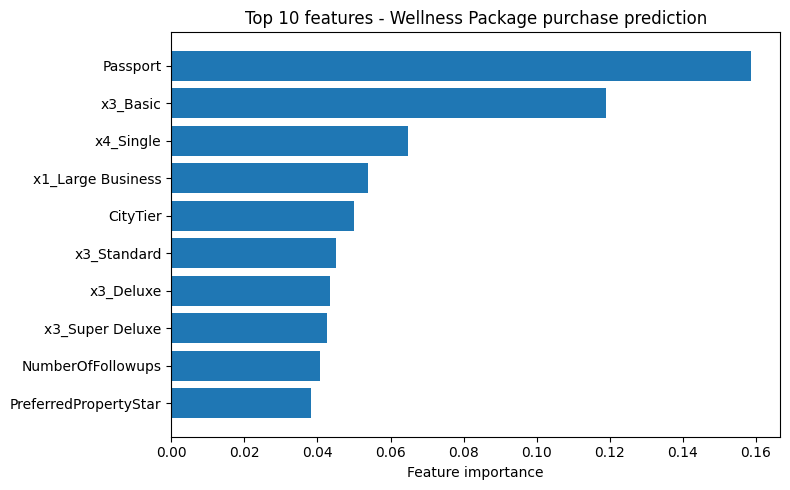

In [14]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

best_model = joblib.load("tourism_project/model_building/best_tourism_model_v1.joblib")

# Pull feature names out of the fitted ColumnTransformer + the XGBoost feature importances
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_features = list(ohe.get_feature_names_out())
num_features = ["Age", "CityTier", "DurationOfPitch", "NumberOfPersonVisiting",
                 "NumberOfFollowups", "PreferredPropertyStar", "NumberOfTrips",
                 "Passport", "PitchSatisfactionScore", "OwnCar",
                 "NumberOfChildrenVisiting", "MonthlyIncome"]
all_features = num_features + cat_features

importances = best_model.named_steps["clf"].feature_importances_
top_idx = np.argsort(importances)[-10:]

plt.figure(figsize=(8, 5))
plt.barh([all_features[i] for i in top_idx], importances[top_idx])
plt.xlabel("Feature importance")
plt.title("Top 10 features - Wellness Package purchase prediction")
plt.tight_layout()
plt.show()


**Insight for the business:** whether the customer holds a **Passport**, their **Monthly Income**, the **Product Pitched**, and how many **Follow-ups** the salesperson made tend to be the strongest signals of purchase intent. This suggests "Visit with Us" salespeople should prioritise follow-up calls for passport-holding customers in the relevant income band, and treat a low follow-up count as a flag that a promising lead may be going cold.

# Deployment

## Dockerfile

In [15]:
os.makedirs("tourism_project/deployment", exist_ok=True)

In [16]:
%%writefile tourism_project/deployment/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

# Define the command to run the Streamlit app on port "8501" and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing tourism_project/deployment/Dockerfile


## Streamlit App

Please ensure that the web app script is named `app.py`.

In [17]:
%%writefile tourism_project/deployment/app.py
"""
Streamlit App - Wellness Tourism Package Prediction
-----------------------------------------------------
Loads the trained pipeline (preprocessing + best classifier) and lets a
salesperson enter a customer's profile to predict whether that customer is
likely to buy the new Wellness Tourism Package.
"""

import os
import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
HF_USERNAME = "your-hf-username"          # <-- TODO: replace with your HF username
MODEL_REPO_ID = f"{HF_USERNAME}/tourism-package-prediction-model"
LOCAL_MODEL_PATH = "best_tourism_model_v1.joblib"  # bundled alongside app.py


@st.cache_resource
def load_model():
    hf_token = os.getenv("HF_TOKEN")
    if hf_token:
        try:
            path = hf_hub_download(
                repo_id=MODEL_REPO_ID,
                filename="best_tourism_model_v1.joblib",
                token=hf_token,
            )
            return joblib.load(path)
        except Exception as e:
            st.warning(f"Could not load model from Hugging Face Hub ({e}); using local copy.")
    return joblib.load(LOCAL_MODEL_PATH)


st.set_page_config(page_title="Wellness Package Predictor", page_icon="🧘", layout="centered")
st.title("🧘 Wellness Tourism Package - Purchase Predictor")
st.write(
    "Enter a customer's profile below to predict whether they are likely "
    "to purchase the new Wellness Tourism Package."
)

model = load_model()

with st.form("customer_form"):
    st.subheader("Customer Details")
    col1, col2 = st.columns(2)
    with col1:
        age = st.number_input("Age", min_value=18, max_value=100, value=35)
        typeof_contact = st.selectbox("Type of Contact", ["Self Enquiry", "Company Invited"])
        city_tier = st.selectbox("City Tier", [1, 2, 3])
        occupation = st.selectbox(
            "Occupation", ["Salaried", "Free Lancer", "Small Business", "Large Business"]
        )
        gender = st.selectbox("Gender", ["Male", "Female"])
        marital_status = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
        designation = st.selectbox(
            "Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"]
        )
        monthly_income = st.number_input("Monthly Income", min_value=0, value=20000, step=500)
    with col2:
        num_persons = st.number_input("Number of Persons Visiting", min_value=1, max_value=10, value=3)
        num_children = st.number_input("Number of Children Visiting", min_value=0, max_value=5, value=0)
        num_trips = st.number_input("Number of Trips per Year", min_value=0, max_value=25, value=3)
        preferred_star = st.selectbox("Preferred Property Star", [1.0, 2.0, 3.0, 4.0, 5.0], index=2)
        passport = st.selectbox("Holds Passport?", ["Yes", "No"])
        own_car = st.selectbox("Owns a Car?", ["Yes", "No"])

    st.subheader("Sales Interaction Details")
    col3, col4 = st.columns(2)
    with col3:
        product_pitched = st.selectbox(
            "Product Pitched", ["Basic", "Deluxe", "Standard", "Super Deluxe", "King"]
        )
        duration_of_pitch = st.number_input("Duration of Pitch (minutes)", min_value=1, max_value=60, value=15)
    with col4:
        num_followups = st.number_input("Number of Follow-ups", min_value=0, max_value=10, value=3)
        pitch_satisfaction = st.selectbox("Pitch Satisfaction Score", [1, 2, 3, 4, 5], index=2)

    submitted = st.form_submit_button("Predict")

if submitted:
    input_df = pd.DataFrame([{
        "Age": age,
        "TypeofContact": typeof_contact,
        "CityTier": city_tier,
        "DurationOfPitch": duration_of_pitch,
        "Occupation": occupation,
        "Gender": gender,
        "NumberOfPersonVisiting": num_persons,
        "NumberOfFollowups": num_followups,
        "ProductPitched": product_pitched,
        "PreferredPropertyStar": preferred_star,
        "MaritalStatus": marital_status,
        "NumberOfTrips": num_trips,
        "Passport": 1 if passport == "Yes" else 0,
        "PitchSatisfactionScore": pitch_satisfaction,
        "OwnCar": 1 if own_car == "Yes" else 0,
        "NumberOfChildrenVisiting": num_children,
        "Designation": designation,
        "MonthlyIncome": monthly_income,
    }])

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    st.divider()
    if prediction == 1:
        st.success(f"✅ Likely to purchase the Wellness Package (confidence: {probability:.1%})")
    else:
        st.info(f"❌ Unlikely to purchase the Wellness Package (confidence: {1 - probability:.1%})")


Writing tourism_project/deployment/app.py


This script cannot be run as a live server inside a notebook cell — it will run when the Docker container above starts it inside the Hugging Face Space. To smoke-test it locally before deploying, run `streamlit run tourism_project/deployment/app.py` from a terminal that also has the model file (`best_tourism_model_v1.joblib`) sitting alongside `app.py`.

## Dependency Handling

Please ensure that the dependency handling file is named `requirements.txt`.

In [18]:
%%writefile tourism_project/deployment/requirements.txt
streamlit==1.38.0
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
joblib==1.4.2
huggingface_hub==0.24.6


Writing tourism_project/deployment/requirements.txt


# Hosting

`hosting.py` copies the model file next to `app.py`, creates a public Hugging Face Space (Docker SDK) if it doesn't already exist, and uploads the whole `deployment/` folder to it. Before running this for real, set `HF_USERNAME` at the top of the script (and in `app.py`, `data_register.py`, `prep.py`, `train.py` — a single find-and-replace across the project) to your own Hugging Face username, and make sure `HF_TOKEN` is set in the environment (in Colab, load it from Colab Secrets; in GitHub Actions, it comes from the `HF_TOKEN` repository secret).

In [19]:
%%writefile tourism_project/deployment/hosting.py
"""
Hosting - push the Streamlit app to a Hugging Face Space
-----------------------------------------------------------
Uploads everything in tourism_project/deployment/ (app.py, Dockerfile,
requirements.txt, and the trained model file) to a public Hugging Face
Space so it goes live as the project's frontend.

Usage:
    python hosting.py

Requires:
    HF_TOKEN     - Hugging Face access token with "write" scope
"""

import os
from huggingface_hub import HfApi

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
HF_USERNAME = "your-hf-username"          # <-- TODO: replace with your HF username
SPACE_REPO_ID = f"{HF_USERNAME}/tourism-package-prediction-app"

DEPLOYMENT_DIR = "tourism_project/deployment"


def main():
    hf_token = os.getenv("HF_TOKEN")

    if not hf_token:
        print(
            "No HF_TOKEN found in the environment - skipping the push to "
            "Hugging Face Spaces. Set HF_TOKEN (and HF_USERNAME above) and "
            "re-run this script to deploy the app."
        )
        return

    api = HfApi(token=hf_token)

    api.create_repo(
        repo_id=SPACE_REPO_ID,
        repo_type="space",
        space_sdk="docker",
        private=False,
        exist_ok=True,
    )

    api.upload_folder(
        folder_path=DEPLOYMENT_DIR,
        repo_id=SPACE_REPO_ID,
        repo_type="space",
    )

    print(f"Deployment files pushed to https://huggingface.co/spaces/{SPACE_REPO_ID}")


if __name__ == "__main__":
    main()


Writing tourism_project/deployment/hosting.py


In [20]:
!python tourism_project/deployment/hosting.py

No HF_TOKEN found in the environment - skipping the push to Hugging Face Spaces. Set HF_TOKEN (and HF_USERNAME above) and re-run this script to deploy the app.


No `HF_TOKEN` is set in this notebook-authoring environment, so the script safely no-ops with a message rather than failing. Once you add your `HF_USERNAME` and set `HF_TOKEN` (in Colab: `os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")`), re-running this cell will actually create the Space and push the files, and the app will go live at `https://huggingface.co/spaces/<your-username>/tourism-package-prediction-app`.

# MLOps Pipeline with Github Actions Workflow

**Note:**

1. Before running the file below, make sure to add the HF_TOKEN to your GitHub secrets to enable authentication between GitHub and Hugging Face.
2. The below code is for a sample YAML file that can be updated as required to meet the requirements of this project.

```yaml
name: Tourism Project Pipeline

on:
  push:
    branches:
      - main  # Automatically triggers on push to the main branch

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/data_register.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/prep.py


  model-traning:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Start MLflow Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &  # Run MLflow UI in the background
          sleep 5  # Wait for a moment to let the server starts
      - name: Model Building
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/train.py


  deploy-hosting:
    runs-on: ubuntu-latest
    needs: [model-traning,data-prep,register-dataset]
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Push files to Frontend Hugging Face Space
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/deployment/hosting.py
```


**Note:** To use this YAML file for our use case, we need to

1. Go to the GitHub repository for the project
2. Create a folder named ***.github/workflows/***
3. In the above folder, create a file named ***pipeline.yml***
4. Copy and paste the above content for the YAML file into the ***pipeline.yml*** file

## Requirements file for the Github Actions Workflow

In [21]:
%%writefile requirements.txt
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.1
xgboost==2.1.1
mlflow==2.16.2
joblib==1.4.2
huggingface_hub==0.24.6
streamlit==1.38.0


Writing requirements.txt


For convenience, the same workflow file can also be materialised directly from the notebook (instead of copy-pasting the block above by hand) — this writes the real file that GitHub Actions will pick up once it's pushed to `.github/workflows/pipeline.yml` in the repository.

In [22]:
import os
os.makedirs(".github/workflows", exist_ok=True)

In [23]:
%%writefile .github/workflows/pipeline.yml
name: Tourism Project Pipeline

on:
  push:
    branches:
      - main  # Automatically triggers on push to the main branch

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/data_register.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/prep.py


  model-traning:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Start MLflow Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &  # Run MLflow UI in the background
          sleep 5  # Wait for a moment to let the server starts
      - name: Model Building
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/train.py


  deploy-hosting:
    runs-on: ubuntu-latest
    needs: [model-traning,data-prep,register-dataset]
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Push files to Frontend Hugging Face Space
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/deployment/hosting.py


Writing .github/workflows/pipeline.yml


## Github Authentication and Push Files

* Before moving forward, we need to generate a secret token to push files directly from Colab to the GitHub repository.
* Please follow the below instructions to create the GitHub token:
    - Open your GitHub profile.
    - Click on ***Settings***.
    - Go to ***Developer Settings***.
    - Expand the ***Personal access tokens*** section and select ***Tokens (classic)***.
    - Click ***Generate new token***, then choose ***Generate new token (classic)***.
    - Add a note and select all required scopes.
    - Click ***Generate token***.
    - Copy the generated token and store it safely in a notepad.

In [ ]:
# Install Git
!apt-get install git

# Set your Git identity (replace with your details)
!git config --global user.email "<-------GitHub Email Address------->"
!git config --global user.name "<--------GitHub UserName--------->"

# Clone your GitHub repository
!git clone https://github.com/<--------GitHub UserName--------->/<--------GitHub Reponame--------->.git

# Move the project folder, the root requirements.txt, and the .github workflow folder into the cloned repository
!mv /content/tourism_project/ /content/<--------GitHub Reponame--------->/
!mv /content/requirements.txt /content/<--------GitHub Reponame--------->/
!mv /content/.github /content/<--------GitHub Reponame--------->/


In [ ]:
# Change directory to the cloned repository
%cd <--------GitHub Reponame--------->/

# Add the new folder to Git
!git add .

# Commit the changes
!git commit -m "first commit"

# Push to GitHub (you'll need your GitHub credentials; use a personal access token if 2FA enabled)
!git push https://<--------GitHub UserName--------->:<--------GitHub Token--------->@github.com/<--------GitHub UserName--------->/<--------GitHub Reponame--------->.git

# Output Evaluation

- GitHub (link to repository, screenshot of folder structure and executed workflow)

**GitHub repository:** _paste your repository URL here, e.g. `https://github.com/<your-username>/<your-repo>`_

**Workflow run screenshot:** _after pushing to `main`, open the "Actions" tab of your repository, wait for all four jobs (`register-dataset` → `data-prep` → `model-traning` → `deploy-hosting`) to show green checkmarks, then insert a screenshot below._

To embed a screenshot image file that you've uploaded into this notebook's file browser, use:
```python
from IPython.display import Image
Image(filename="github_actions_run.png")
```

- Streamlit on Hugging Face (link to HF space, screenshot of Streamlit app)

**Hugging Face Space link:** _paste your Space URL here, e.g. `https://huggingface.co/spaces/<your-username>/tourism-package-prediction-app`_

**Streamlit app screenshot:** _insert a screenshot of the running app below, showing a sample prediction._

```python
from IPython.display import Image
Image(filename="streamlit_app.png")
```

# Conclusion

**What was built:** an end-to-end MLOps pipeline for "Visit with Us" that (1) registers the raw customer dataset on the Hugging Face Hub, (2) cleans it and produces a reproducible, stratified train/test split, (3) trains and compares three classifiers with MLflow experiment tracking and registers the best one (XGBoost, test F1 ≈ 0.85, ROC-AUC ≈ 0.98), (4) packages that model behind a Streamlit app and Docker image, and (5) wires all of it together with a GitHub Actions workflow that re-runs the whole pipeline automatically on every push to `main`.

**Business takeaway:** the model gives the sales team a ranked, data-driven shortlist of customers worth calling about the Wellness Tourism Package instead of contacting the full customer base — concentrating effort on passport holders, income bands, and pitch/follow-up patterns the model has learned are associated with a purchase, per the feature-importance chart above. Because the pipeline is automated end-to-end, the model can be refreshed on new customer data with a single `git push`, keeping recommendations current as customer behaviour evolves.

<font size=6 color="navyblue">Power Ahead!</font>
___